# Exploratory Data Analysis (EDA)

## Objective

Explore and understand the dataset to identify patterns, relationships, missing values, outliers, and other characteristics before preprocessing and model building.

---

## Questions

1. How is the target variable distributed?
2. Are there outliers?
3. Are there missing values?
4. Which numerical features correlate with the target?
5. Is numerical features are correlated with each others?
6. Which categorical features seem important?
7. Which features may require preprocessing?

---

**1. How is the target variable distributed?**
- The target variable is the quantity that our model is trying to predict. By understanding its distribution, range, skewness, and presence of outliers, we gain insight into the prediction problem itself. This helps us choose appropriate preprocessing techniques, evaluation metrics, and machine learning models. Once we understand the target, we can then study how each feature relates to it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('../data/train.csv')

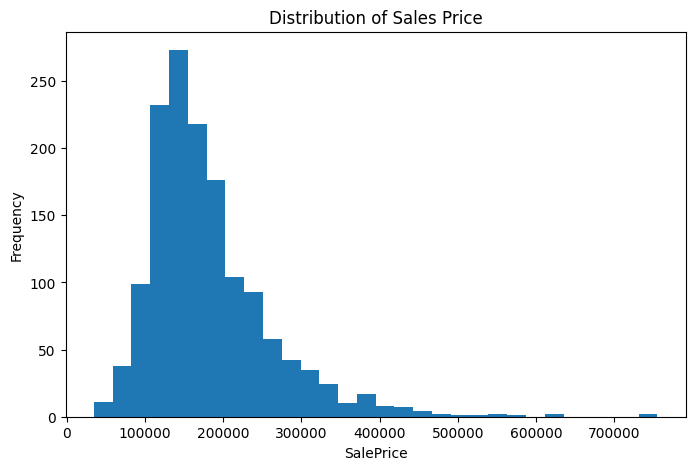

In [3]:
#1 Histogram

plt.figure(figsize=(8,5))
plt.hist(df['SalePrice'],bins=30)
plt.title('Distribution of Sales Price')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()



### Observations
1. The distribution is right-skewed (positively skewed).
  -  Most houses have lower to medium prices.
  - A few houses have very high prices.
  - The right tail of the distribution is longer.

2. There are a few extremely expensive houses that appear to be potential outliers. Further analysis (e.g., using a box plot) is needed to confirm this.

**Q.2 Are there outliers?**

#2 Box Plot
plt.boxplot(df['SalePrice'],vert=True,showmeans=True,showfliers=True,notch=True)
plt.show()

### Observations

- The box (IQR) is relatively narrow compared to the full range of house prices, indicating that the middle 50% of house prices are fairly concentrated.
- There are numerous potential outliers above the upper whisker, suggesting the presence of a small number of very expensive houses.
- The mean is higher than the median, which is consistent with the right-skewed distribution observed in the histogram.

### Decision

- No preprocessing decision has been made yet.
- We will investigate these observations further during EDA and evaluate their impact during model development.


---

**3. Are there missing values?**

In [4]:
#How isnull & count works 

s = pd.Series([10, None, 20, None, 30])
s.count()

np.int64(3)

In [5]:
s.isnull().sum()

np.int64(2)

In [6]:
#get the col wise nullvalues count
null_count=df.isnull().sum()
null_count=null_count[null_count>0]
null_count=null_count.sort_values(ascending=True)

null_count

Electrical         1
MasVnrArea         8
BsmtCond          37
BsmtFinType1      37
BsmtQual          37
BsmtExposure      38
BsmtFinType2      38
GarageType        81
GarageQual        81
GarageFinish      81
GarageCond        81
GarageYrBlt       81
LotFrontage      259
FireplaceQu      690
MasVnrType       872
Fence           1179
Alley           1369
MiscFeature     1406
PoolQC          1453
dtype: int64

In [7]:
total_rows = len(df)



null_percetage=(null_count/total_rows)*100
null_percetage

Electrical       0.068493
MasVnrArea       0.547945
BsmtCond         2.534247
BsmtFinType1     2.534247
BsmtQual         2.534247
BsmtExposure     2.602740
BsmtFinType2     2.602740
GarageType       5.547945
GarageQual       5.547945
GarageFinish     5.547945
GarageCond       5.547945
GarageYrBlt      5.547945
LotFrontage     17.739726
FireplaceQu     47.260274
MasVnrType      59.726027
Fence           80.753425
Alley           93.767123
MiscFeature     96.301370
PoolQC          99.520548
dtype: float64

### Observations

- Observations
- PoolQC has 99.52% missing values.
- MiscFeature has 96.30% missing values.
- Alley has 93.77% missing values.
- Fence has 80.75% missing values.
- MasVnrType has 59.73% missing values.
- FireplaceQu has 47.26% missing values.
- LotFrontage has 17.74% missing values.
- Most of the remaining features have less than 6% missing values.

### Observations

- Features such as `PoolQC`, `GarageType`, `BsmtQual`, `FireplaceQu`, `Alley`, and `MiscFeature` have many missing values because these features are **not applicable** for many houses (e.g., no pool, no garage, no basement).

- Features such as `Electrical` and `LotFrontage` appear to have **genuine missing values**, where the information was not recorded.

### Conclusion

Not all missing values should be treated the same. Before preprocessing, it is important to understand the reason behind the missing values.

---

**Q.4 Which numerical features correlate with the target?**
- We want a numerical measure of how strongly each feature is linearly related to SalePrice
- Correlation tells us how strongly two variables are linearly related.
- Correlation Matrix- gives us correlation b/w all features with each other


In [8]:
#find  numerical features
numerical_df=df.select_dtypes(include=["int64","float64"])

#find corr matrix
corr_matrix = numerical_df.corr()
corr_matrix
saleprice_corr = corr_matrix["SalePrice"]
saleprice_corr = saleprice_corr.sort_values(ascending=False)

#drop ID,SalePrice(not useful)
saleprice_corr=saleprice_corr.drop(['Id','SalePrice'])

#we just want strong corr- sign doesn't matter ()
saleprice_corr_abs=saleprice_corr.abs().sort_values(ascending=False)

saleprice_corr_abs



OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
KitchenAbvGr     0.135907
EnclosedPorch    0.128578
ScreenPorch      0.111447
PoolArea         0.092404
MSSubClass       0.084284
OverallCond      0.077856
MoSold           0.046432
3SsnPorch        0.044584
YrSold           0.028923
LowQualFinSF     0.025606
MiscVal          0.021190
BsmtHalfBath     0.016844
BsmtFinSF2       0.011378
Name: SalePrice, dtype: float64

In [9]:
numerical_df

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,298,0,0,0,0,0,0,5,2007,181500
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,42,0,0,0,0,0,9,2008,223500
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,35,272,0,0,0,0,2,2006,140000
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,6,5,1999,2000,0.0,0,...,0,40,0,0,0,0,0,8,2007,175000
1456,1457,20,85.0,13175,6,6,1978,1988,119.0,790,...,349,0,0,0,0,0,0,2,2010,210000
1457,1458,70,66.0,9042,7,9,1941,2006,0.0,275,...,0,60,0,0,0,0,2500,5,2010,266500
1458,1459,20,68.0,9717,5,6,1950,1996,0.0,49,...,366,0,112,0,0,0,0,4,2010,142125


In [10]:
top10_features = saleprice_corr_abs.head(10)



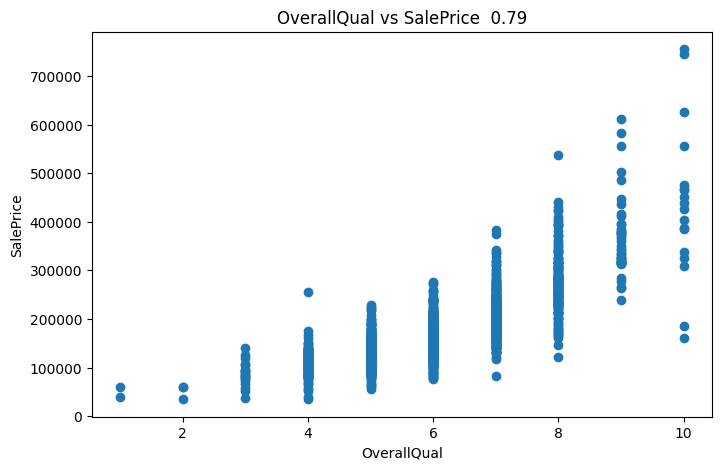

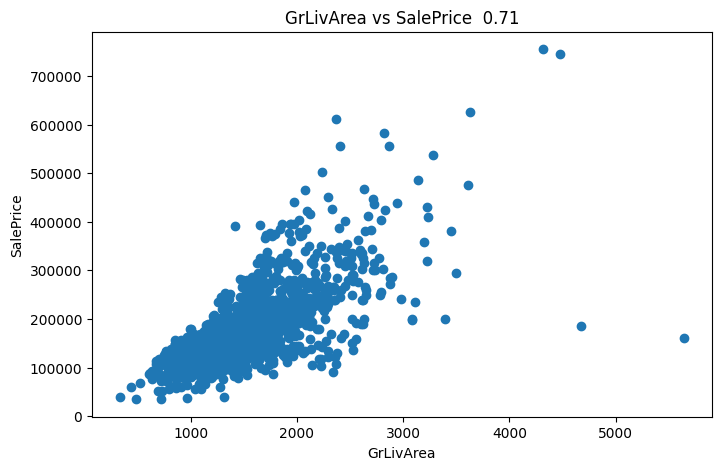

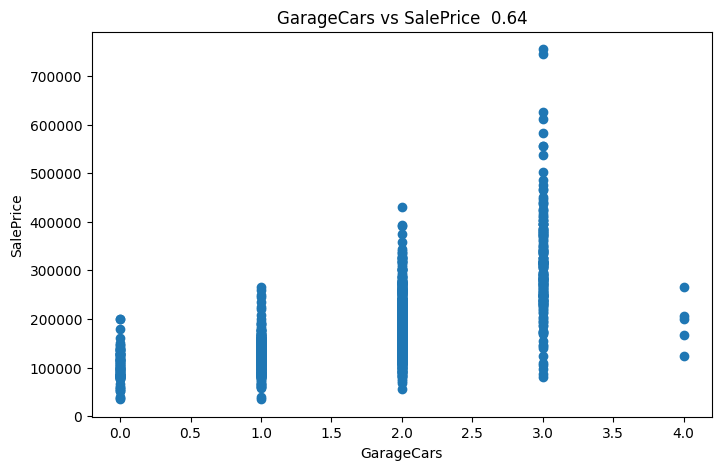

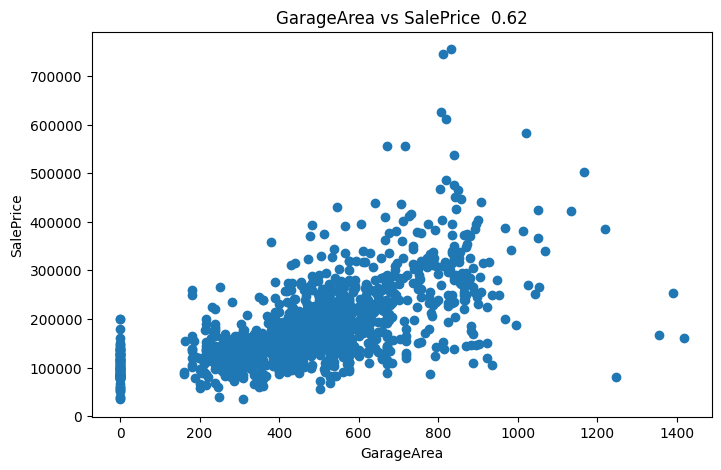

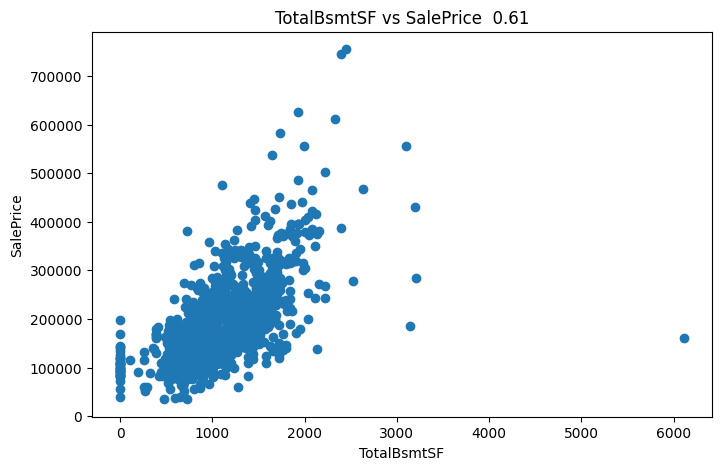

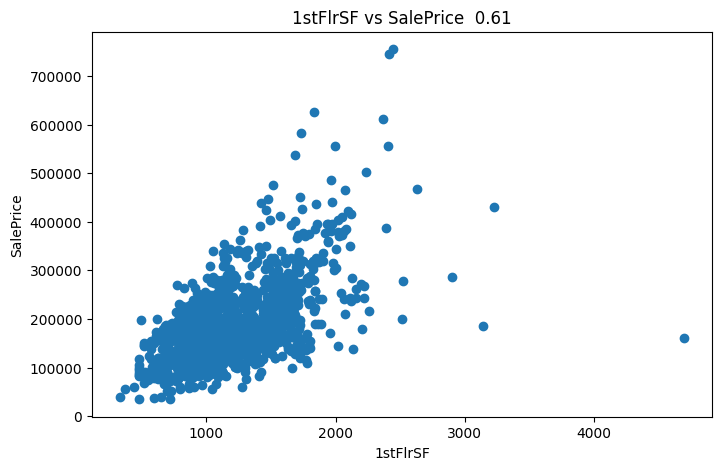

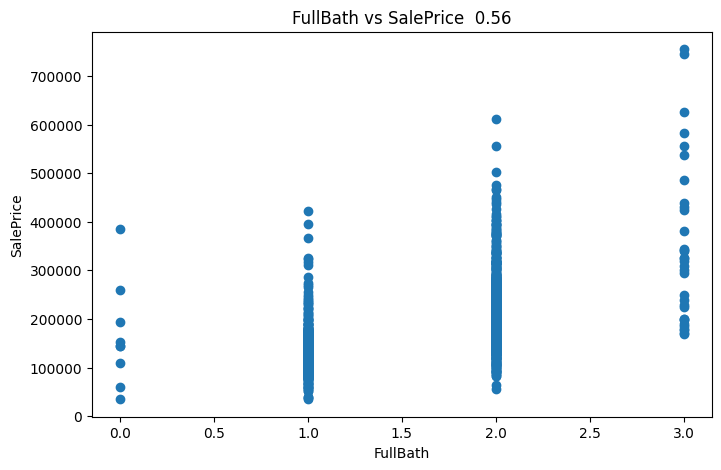

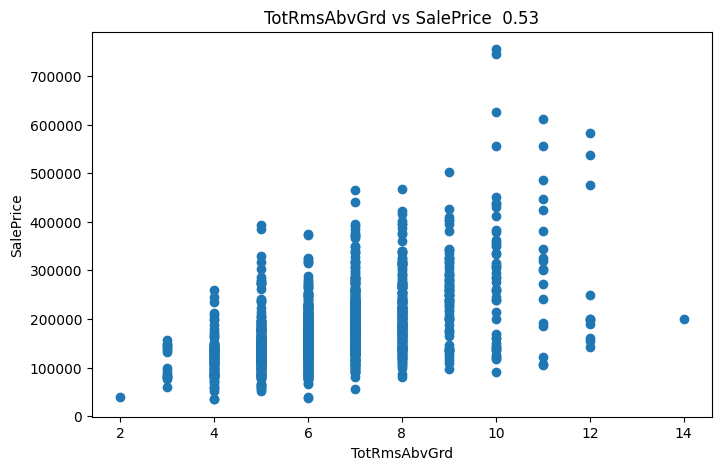

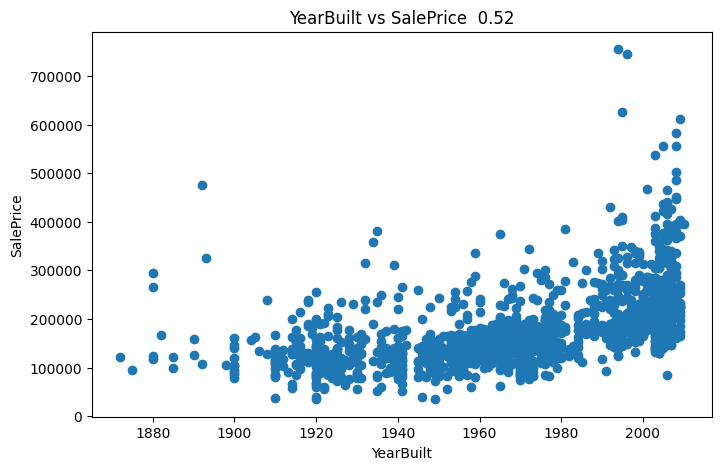

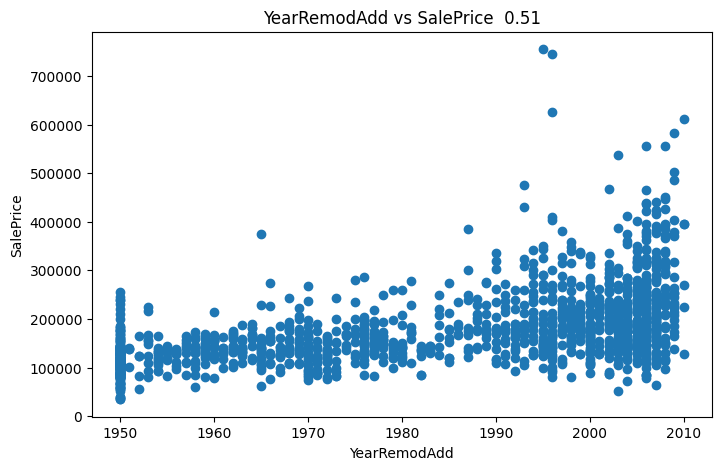

In [11]:
for feature in top10_features.index:
    plt.figure(figsize=(8, 5))

    plt.scatter(df[feature], df["SalePrice"])

    plt.xlabel(feature)
    plt.ylabel("SalePrice")
    plt.title(f"{feature} vs SalePrice  {top10_features[feature]:.2f}")

    plt.show()

### OverallQual vs SalePrice

- Strong positive relationship between OverallQual and SalePrice.
- The relationship is approximately linear.
- Houses with higher overall quality generally have higher sale prices.
- A few houses with high quality ratings have relatively low sale prices, indicating potential outliers.
- The variability of SalePrice increases as OverallQual increases.
- Vertical clusters are visible because OverallQual is a discrete ordinal feature with values ranging from 1 to 10.

### GrLivArea vs SalePrice

- Strong positive relationship between `GrLivArea` and `SalePrice`.
- The relationship is approximately linear.
- Houses with larger above-ground living areas generally have higher sale prices.
- A few potential outliers are visible, particularly houses with unusually large living areas but relatively low sale prices.
- The spread of `SalePrice` increases as `GrLivArea` increases.
- No obvious clusters are observed since `GrLivArea` is a continuous numerical feature.
- Houses with similar living areas can have different sale prices, indicating that other features also influence the target variable.

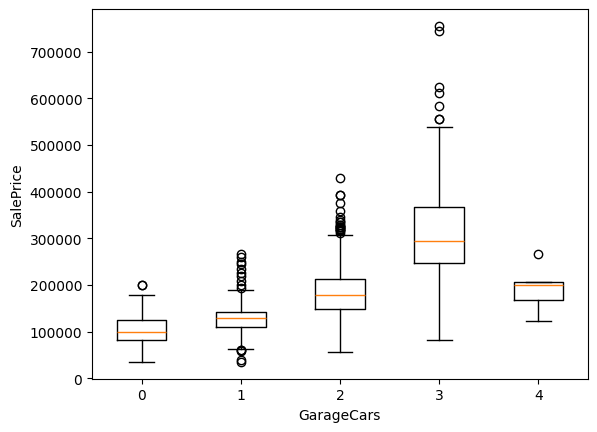

In [12]:
data = [
    df[df["GarageCars"] == 0]["SalePrice"],
    df[df["GarageCars"] == 1]["SalePrice"],
    df[df["GarageCars"] == 2]["SalePrice"],
    df[df["GarageCars"] == 3]["SalePrice"],
    df[df["GarageCars"] == 4]["SalePrice"]
]

plt.boxplot(data, tick_labels=[0, 1, 2, 3, 4])

plt.xlabel("GarageCars")
plt.ylabel("SalePrice")

plt.show()

### GarageCars vs SalePrice

- There is a positive relationship between `GarageCars` and `SalePrice`.
- The relationship is not perfectly linear. Sale prices generally increase as garage capacity increases, but the trend becomes less consistent for very high values of `GarageCars`.
- Houses with a moderate garage capacity tend to have higher sale prices, while houses with very few or unusually many garage spaces are less common and may have lower prices.
- No obvious outliers can be identified from this scatter plot alone.
- It is difficult to conclude whether the spread of `SalePrice` changes significantly with `GarageCars`.
- Vertical clusters are visible because `GarageCars` is a discrete integer feature.
- Houses with the same `GarageCars` value can have different sale prices, indicating that other features also influence the target variable.

### GarageCars vs SalePrice (Box Plot)

- The median `SalePrice` generally increases as `GarageCars` increases from 0 to 3.
- The trend for `GarageCars = 4` is inconclusive because there are very few observations.
- Houses with 3-car garages have the largest variability in sale prices (largest IQR).
- Several high-price outliers are present, especially for houses with 3-car garages.
- The distributions are not perfectly symmetric, as the median is not centered within every box.

### GarageArea vs SalePrice

- Strong positive relationship between `GarageArea` and `SalePrice`.
- The relationship is approximately linear.
- Many houses have garage areas between 200 and 800 sq ft.
- Houses with the same garage area can have different sale prices, indicating that other features also influence the target.
- The spread of `SalePrice` increases as `GarageArea` increases.
- A few potential outliers are visible.

### TotalBsmtSF vs SalePrice

- Positive relationship with `SalePrice`.
- The relationship is approximately linear.
- Houses with similar basement areas can have different sale prices, indicating that basement area alone does not determine house price.
- The spread of `SalePrice` is relatively consistent, with a slight increase for larger basement areas.
- A few potential outliers are visible.
- No obvious clustering is observed since the feature is continuous.

### 1stFlrSF vs SalePrice

- Positive relationship with `SalePrice`.
- The relationship is approximately linear.
- Houses with similar first-floor areas can still have different sale prices.
- The spread of `SalePrice` increases as `1stFlrSF` increases.
- A few potential outliers are present.
- No obvious clustering is observed.

### FullBath vs SalePrice

- Positive relationship with `SalePrice`.
- Houses with more full bathrooms generally tend to have higher sale prices.
- Houses with the same number of full bathrooms can have different sale prices.
- The spread of `SalePrice` increases with the number of bathrooms.
- Vertical clusters are observed because `FullBath` is a discrete integer feature.
- A few potential outliers are present.

### TotRmsAbvGrd vs SalePrice

- Positive relationship with `SalePrice`.
- Houses with more rooms generally tend to have higher sale prices.
- Houses with the same number of rooms can still have different sale prices.
- The spread of `SalePrice` increases as the number of rooms increases.
- Vertical clusters are visible because the feature is discrete.
- A few potential outliers are present.

### YearBuilt / YearRemodAdd vs SalePrice

- There is a positive relationship with `SalePrice`.
- Newer houses generally tend to have higher sale prices.
- The relationship appears weaker than for features such as `OverallQual` or `GrLivArea`.
- Houses built in the same year can have different sale prices, indicating that construction year alone does not determine the target.
- A few potential outliers are visible.
- Vertical clustering is observed because houses are built or remodeled in discrete years.

## Summary of Numerical Feature Analysis wrt SalePrice

- Most important numerical features show a positive relationship with `SalePrice`; as these feature values increase, house prices generally increase.
- Features such as `OverallQual`, `GrLivArea`, `GarageArea`, and `GarageCars` exhibit relatively strong relationships with the target variable.
- Newer houses (`YearBuilt`, `YearRemodAdd`) generally tend to have higher sale prices, although the relationship is weaker than some other features.
- Several numerical features are discrete (e.g., `OverallQual`, `GarageCars`, `FullBath`, `TotRmsAbvGrd`), resulting in vertical clusters in scatter plots.
- Continuous features (e.g., `GrLivArea`, `GarageArea`, `TotalBsmtSF`) show smoother trends without clustering.
- Many features contain potential outliers, which will be investigated during the preprocessing stage.
- For most features, the spread of `SalePrice` increases as the feature value increases.
- Houses with similar values of a single feature can still have different sale prices, indicating that no single feature completely explains the target. Multiple features jointly influence house prices.

---

**5. Is numerical features are correlated with each others?**

In [13]:
num_df = df.select_dtypes(include='number').drop(columns=['Id', 'SalePrice'])
corr_matrix=num_df.corr();
upper_triangular=corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))#convert upper triangilar
corr_pairs = (
    upper_triangular
    .stack(future_stack=True)
    .dropna().abs()
    .sort_values(ascending=False)
)#2d filtered matrix into series list into s

corr_pairs=corr_pairs[corr_pairs>=0.7]
corr_pairs

GarageCars   GarageArea      0.882475
YearBuilt    GarageYrBlt     0.825667
GrLivArea    TotRmsAbvGrd    0.825489
TotalBsmtSF  1stFlrSF        0.819530
dtype: float64

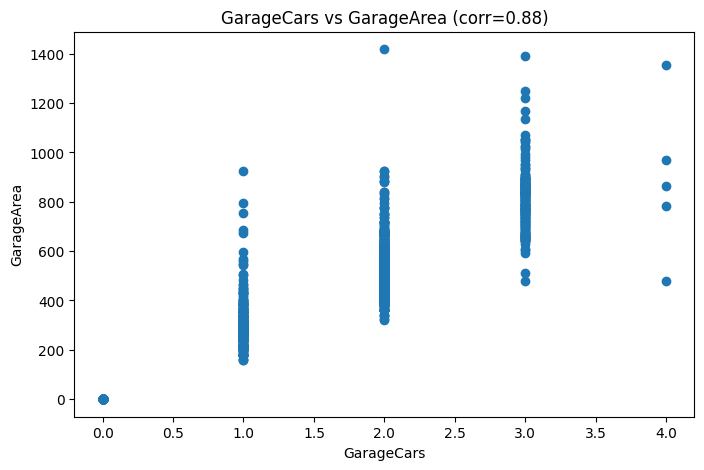

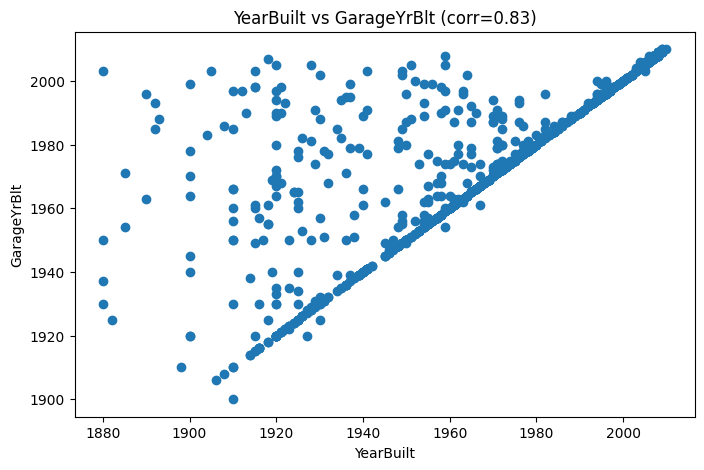

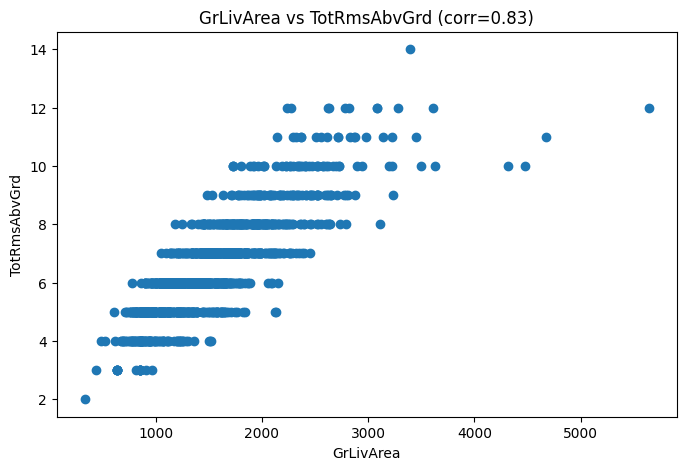

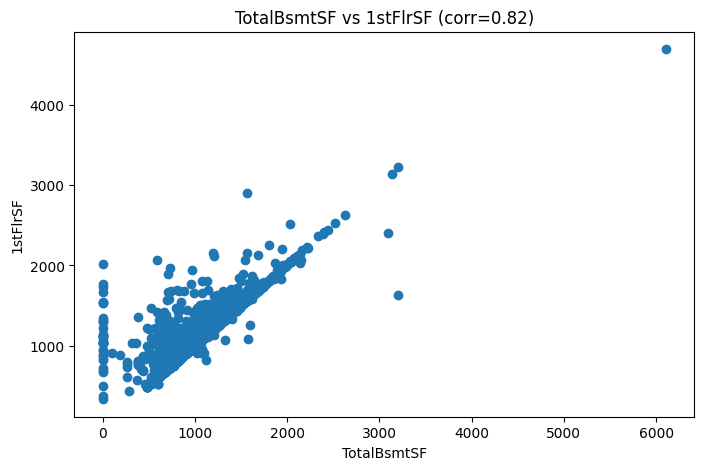

In [14]:
for (feature1, feature2), corr in corr_pairs.items():

    plt.figure(figsize=(8,5))

    plt.scatter(df[feature1], df[feature2])

    plt.xlabel(feature1)
    plt.ylabel(feature2)
    plt.title(f"{feature1} vs {feature2} (corr={corr:.2f})")

    plt.show()


### Numerical Features vs. Numerical Features

### Highly Correlated Feature Pairs

| Feature Pair | Correlation |
|--------------|------------:|
| GarageCars vs GarageArea | 0.882 |
| YearBuilt vs GarageYrBlt | 0.826 |
| GrLivArea vs TotRmsAbvGrd | 0.825 |
| TotalBsmtSF vs 1stFlrSF | 0.820 |

### Overall Observations

- All four feature pairs exhibit a **strong positive correlation** (greater than 0.80).
- Scatter plots confirm an **approximately linear relationship** between each pair.
- As one feature increases, the other generally increases as well.
- These feature pairs describe similar characteristics of a house, indicating **potential feature redundancy**.
- The strong relationships provide **evidence of possible multicollinearity**, particularly for linear regression models.

---

### 1. GarageCars vs GarageArea

**Observations:**

- A strong positive linear relationship exists between the number of garage spaces and the garage area.
- Larger garages generally accommodate more vehicles, which explains the high correlation.
- Vertical clustering is observed because **GarageCars** is a discrete numerical feature.
- A few potential outliers are present for houses with four-car garages.
- Since both features describe garage size, they may contain overlapping information.

---

### 2. YearBuilt vs GarageYrBlt

**Observations:**

- A strong positive linear relationship is observed.
- Most houses have the same **YearBuilt** and **GarageYrBlt**, indicating that garages were typically constructed along with the house.
- A small number of houses have garages built later, appearing as points away from the main diagonal.
- These features represent closely related construction information and may introduce redundancy.

---

### 3. GrLivArea vs TotRmsAbvGrd

**Observations:**

- A strong positive relationship exists between above-ground living area and the total number of rooms.
- Houses with more rooms generally have a larger living area.
- Vertical clustering is visible because **TotRmsAbvGrd** is a discrete count feature.
- Although related, these features capture different aspects of a house (living area vs. room count), so each may still provide useful information.

---

### 4. TotalBsmtSF vs 1stFlrSF

**Observations:**

- A strong positive, approximately linear relationship is observed.
- Houses with larger first-floor areas generally also have larger basements.
- Most houses have first-floor areas that are equal to or larger than their basement areas.
- A clear cluster at **0 basement area** represents houses without basements.
- These features both describe the overall footprint of a house and therefore may contain overlapping information.

---

### Final Conclusion

The scatter plots validate the strong correlations identified in the correlation matrix. Several feature pairs describe similar structural characteristics of a house, such as garage size, construction year, living space, and house footprint. These relationships suggest **potential multicollinearity**, which should be considered when building linear regression models. However, no features are removed at this stage; feature selection decisions will be made during model building and evaluation.

---

**6. Which categorical features seem important?***

# Categorical Features vs. SalePrice

## Objective

The goal of this analysis is to understand how different categorical features influence the target variable (`SalePrice`) and identify the most informative categorical variables for the prediction task.

---

## Key Decisions

### 1. Appropriate Visualization

#### Box Plot (Primary Choice)

**Reason:**

A box plot allows us to compare the distribution of `SalePrice` across different categories.

It provides information about:

- Median sale price
- Interquartile Range (IQR)
- Spread of prices
- Potential outliers
- Differences in distribution between categories

Since EDA aims to understand the complete distribution rather than a single summary statistic, box plots are the preferred visualization.

---

#### Bar Plot (Secondary Choice)

A bar plot displays an aggregated statistic for each category, such as:

- Mean SalePrice
- Median SalePrice
- Count of observations

Although useful for summarizing data, bar plots do not show the variability or distribution within each category.

Therefore, bar plots are not the primary choice during exploratory analysis.

---

### 2. Should Every Categorical Feature Be Analyzed?

**Decision: No**

The dataset contains a large number of categorical features.

Analyzing every feature individually would be time-consuming and may provide limited additional insight.

Instead, we will prioritize the most informative categorical features.

This approach is closer to industry practice and allows us to focus on features that are more likely to influence the target variable.

---

### 3. How Will Important Features Be Selected?

Two sources of information will be used:

#### Domain Knowledge

Features that are expected to influence house prices, such as:

- Neighborhood
- Overall Quality
- Kitchen Quality
- Exterior Quality
- Basement Quality
- Garage Finish

are naturally good candidates for detailed analysis.

#### Statistical Evidence

Instead of manually inspecting every categorical feature, summary statistics will be used to identify promising features before visualization.

---

### 4. Why Not Use Correlation?

Pearson correlation measures the strength of a **linear relationship between numerical variables**.

Since categorical features consist of labels rather than numerical values, Pearson correlation cannot be directly applied.

Therefore, a different approach is required for categorical feature analysis.

---

### 5. Mean vs. Median

Although the mean can summarize the average sale price for each category, it is sensitive to extreme values.

Earlier target variable analysis showed that **SalePrice is right-skewed and contains potential outliers**.

Therefore, the **median** is generally a more robust measure of central tendency for comparing categories during EDA.

---

## Planned Workflow

1. Identify categorical features.
2. Prioritize the most informative features using domain knowledge and summary statistics.
3. Visualize selected features using box plots.
4. Analyze how `SalePrice` changes across different categories.
5. Identify categorical variables that appear to have a strong influence on house prices.
6. Use these observations to guide preprocessing and model building.

---

In [15]:
#Step 1: Identify Categorical Features
cat_cols = df.select_dtypes(include="str").columns

In [16]:
cat_cols

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')

In [17]:
#Step 2: Check how many unique categories each feature has.
cat_summary=pd.DataFrame({'Unique Categories':df[cat_cols].nunique(),
                         'Missing Values':df[cat_cols].isnull().sum()})
cat_summary.sort_values("Unique Categories", ascending=False)

,Unique Categories,Missing Values
Neighborhood,25,0
Exterior2nd,16,0
Exterior1st,15,0
Condition1,9,0
SaleType,9,0
HouseStyle,8,0
RoofMatl,8,0
Condition2,8,0
Functional,7,0
BsmtFinType2,6,38


In [18]:
#Step 3:Select Important Features
important_cat = [
    "Neighborhood",
    "MSZoning",
    "HouseStyle",
    "ExterQual",
    "KitchenQual",
    "BsmtQual",
    "GarageFinish",
    "GarageType",
    "Foundation",
    "SaleCondition"
]

**Why these?**
- Neighborhood → Location is a major factor in house prices.
- MSZoning → Land-use regulations can affect value.
- HouseStyle → Different styles appeal differently to buyers.
- ExterQual → Overall exterior quality.
- KitchenQual → Kitchen quality strongly influences price.
- BsmtQual → Basement quality matters.
- GarageFinish → Finished garages often add value.
- GarageType → Attached vs. detached garages can influence price.
- Foundation → Different foundation types may correlate with price.
- SaleCondition → Some sale conditions affect the selling price.

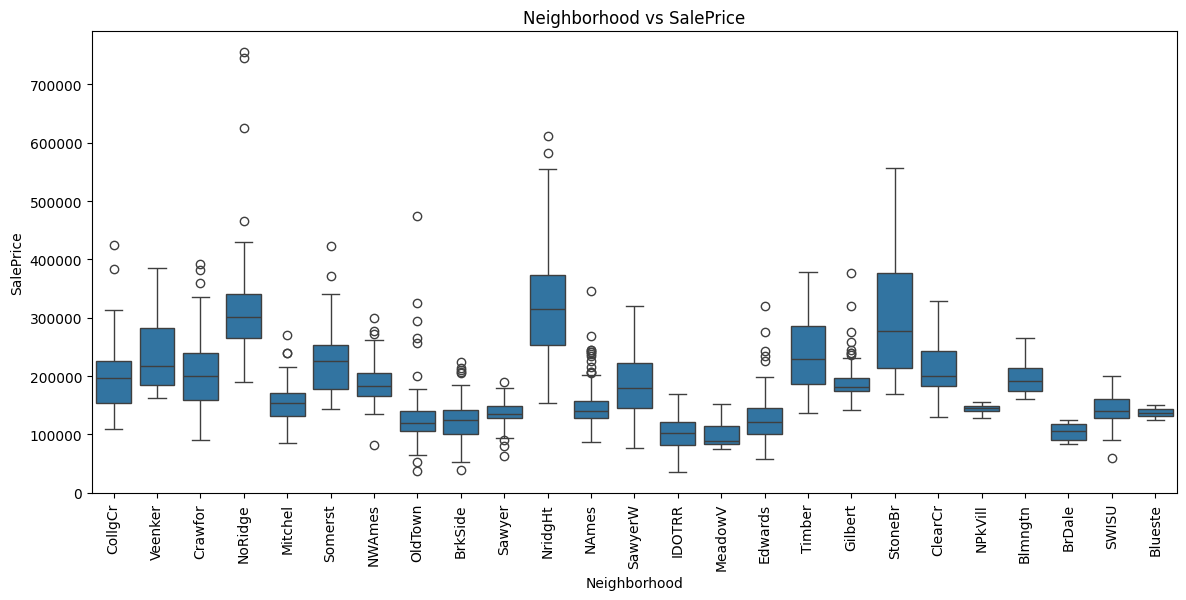

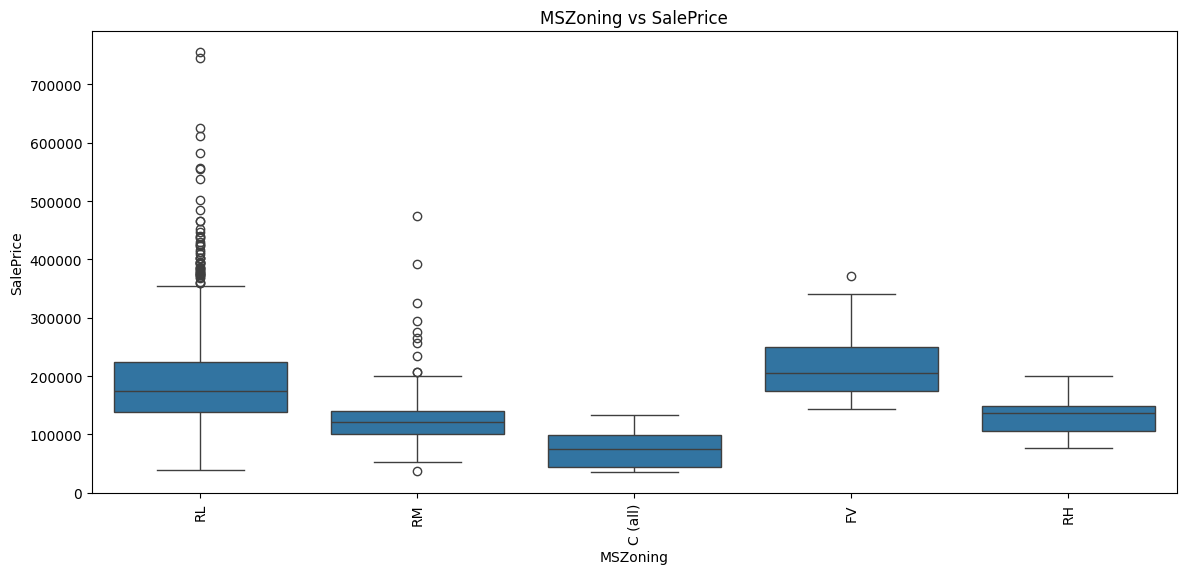

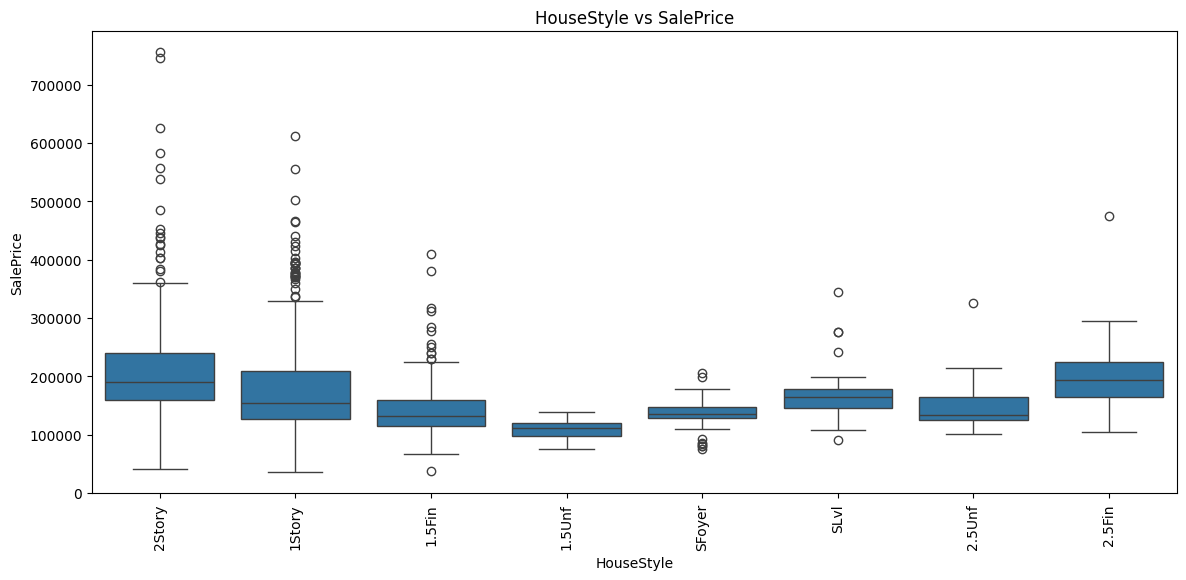

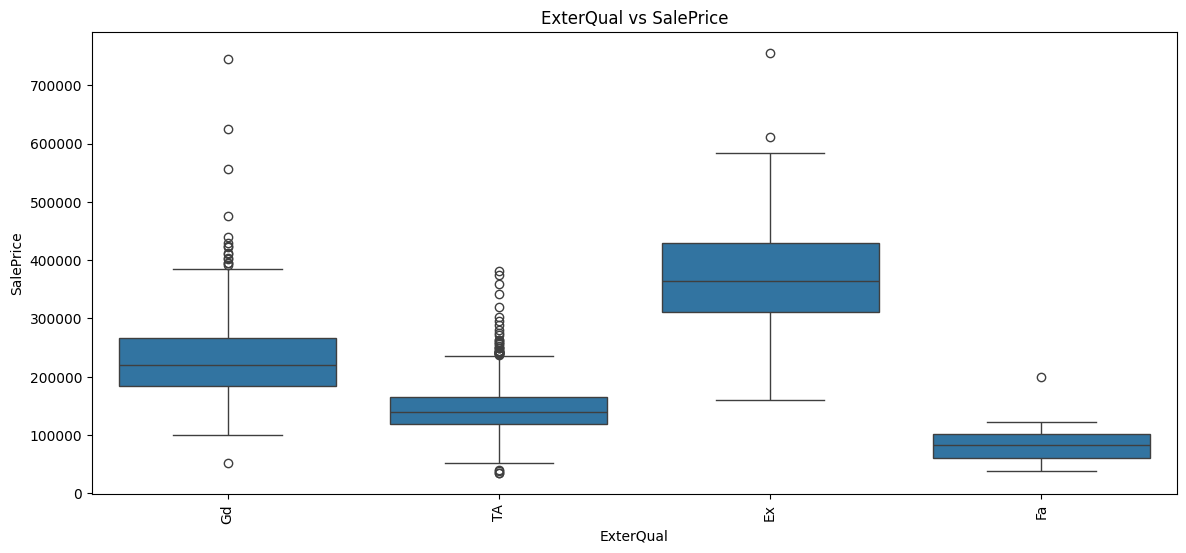

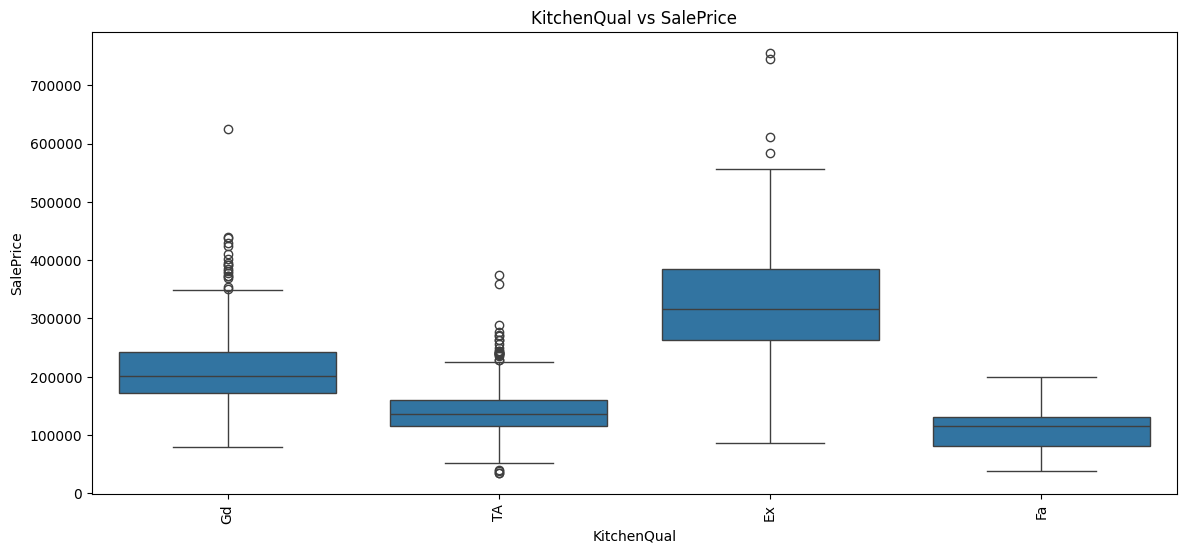

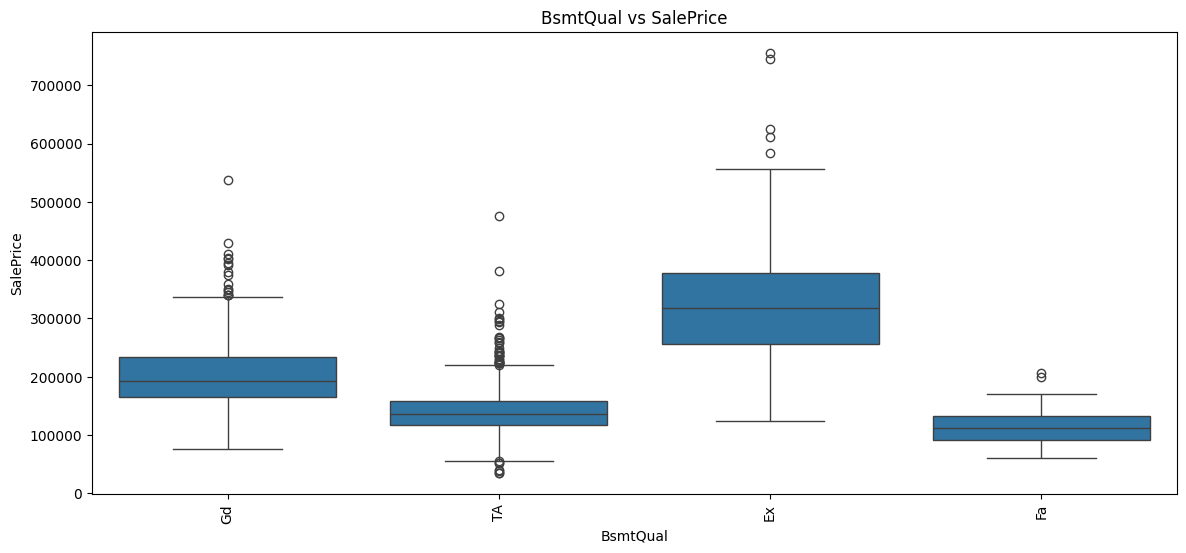

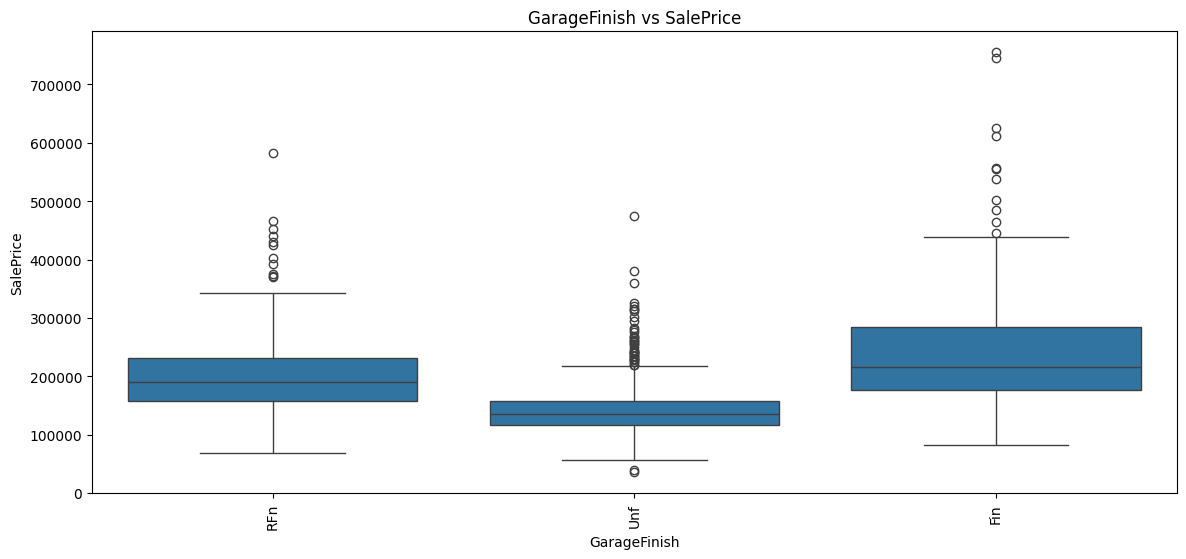

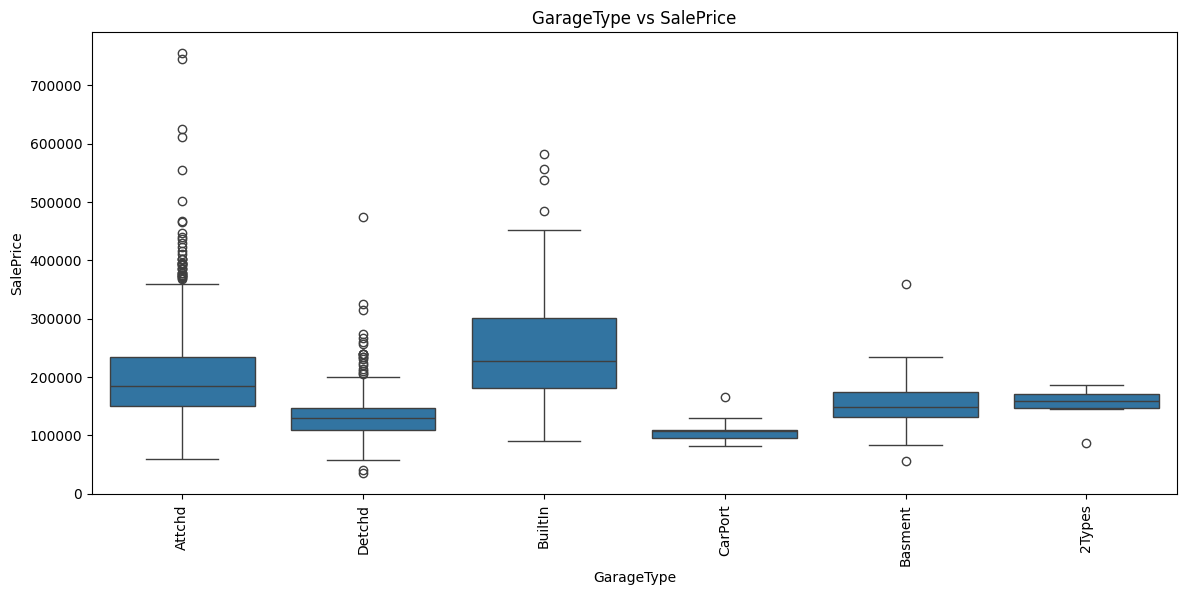

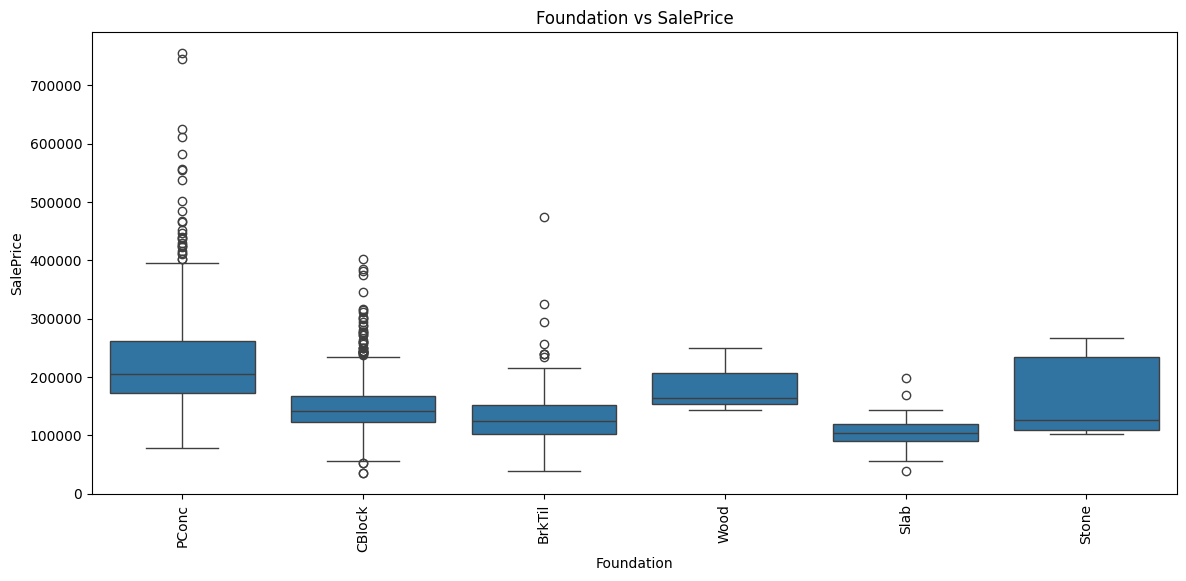

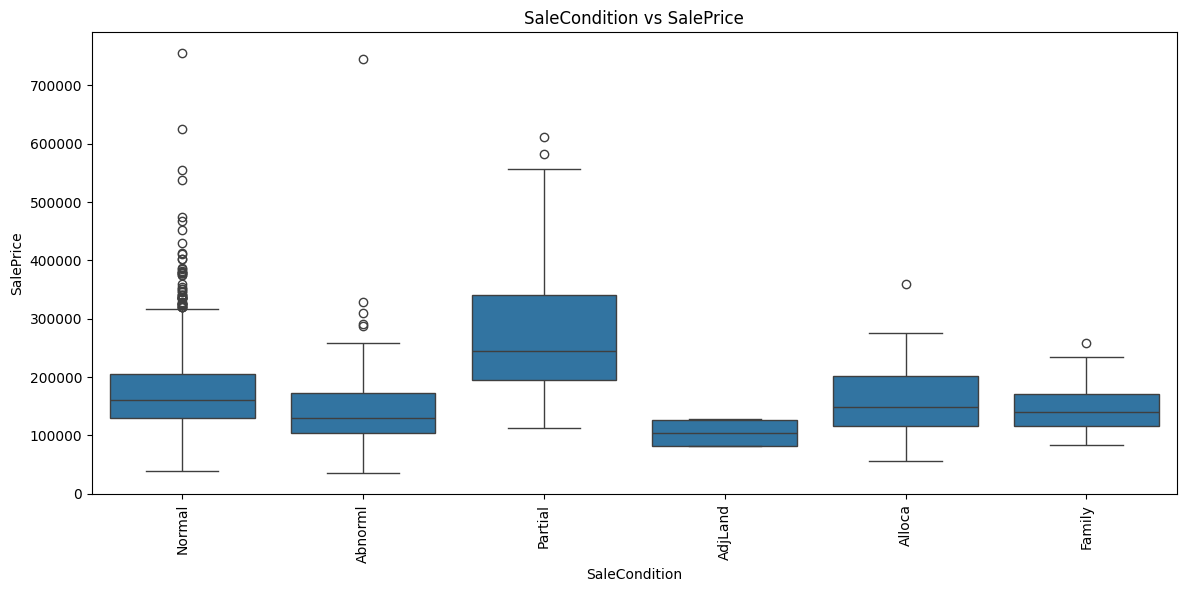

In [23]:
import seaborn as sns
for feature in important_cat:
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df, x=feature, y="SalePrice")
    plt.xticks(rotation=90)
    plt.title(f"{feature} vs SalePrice")
    plt.show()



## 1. Neighborhood vs. SalePrice

### Observations

- There is a substantial variation in median SalePrice across different neighborhoods.
- **NridgHt** has the highest median SalePrice, whereas **MeadowV** has the lowest median SalePrice.
- **StoneBr** exhibits one of the largest spreads in SalePrice, indicating greater variability in house prices within that neighborhood.
- Several neighborhoods contain high-price outliers, suggesting the presence of premium houses even within neighborhoods that generally have lower median prices.
- The spread of SalePrice differs across neighborhoods, indicating that price variability is not uniform across all locations.

### Conclusion

Neighborhood appears to be a strong predictor of SalePrice. Houses located in different neighborhoods exhibit noticeably different price distributions, making this feature valuable for predictive modeling.

---

## 2. HouseStyle vs. SalePrice

### Observations

- SalePrice varies across different house styles.
- **2.5Fin** has the highest median SalePrice, whereas **1.5Unf** has the lowest.
- **1Story** and **2Story** exhibit relatively wide spreads in SalePrice, indicating higher price variability.
- **1Story** and **2Story** also contain the largest number of high-price outliers, suggesting the presence of premium houses within these styles.
- Although the price distributions differ across house styles, there is considerable overlap between categories.

### Conclusion

HouseStyle appears to influence SalePrice, but its effect is less pronounced than that of Neighborhood. It is a useful feature, though likely a weaker predictor compared to Neighborhood.

## 3. Quality Features vs. SalePrice

### Features
- ExterQual
- BsmtQual
- KitchenQual

### Observations

- All three quality-related features exhibit a similar trend.
- As the quality rating improves, the median SalePrice consistently increases.
- Higher-quality categories generally have higher SalePrice distributions.
- The distributions show relatively clear separation between quality levels, indicating a strong relationship with SalePrice.

### Conclusion

Exterior quality, basement quality, and kitchen quality are strong predictors of SalePrice. Houses with better quality ratings consistently sell for higher prices.

 ## 4. GarageFinish vs. SalePrice

### Observations

- SalePrice varies across different garage finish categories.
- Houses with **finished garages** generally have higher SalePrice distributions than those with **unfinished or unfinished-like garages**.
- As the level of garage completion improves, the median SalePrice generally increases.
- All categories contain some high-price outliers, indicating the presence of premium houses.

### Conclusion

GarageFinish appears to be a useful predictor of SalePrice. Houses with more completely finished garages tend to have higher selling prices.

## 5. GarageType vs. SalePrice

### Observations

- Houses with **built-in garages (BuiltIn)** generally have the highest SalePrice distribution.
- **BuiltIn** garages also show the widest spread, indicating greater variability in house prices.
- The price distributions of different garage types overlap considerably, suggesting that GarageType alone does not fully explain SalePrice.
- **Attached garages (Attchd)** contain the largest number of high-price outliers, indicating the presence of many premium houses.

### Conclusion

GarageType has some relationship with SalePrice, but the separation between categories is not as strong as features such as Neighborhood or quality-related features.

## 6. Foundation vs. SalePrice

### Observations

- Houses with **PConc (Poured Concrete)** foundations have the highest median SalePrice.
- **Slab** foundations have the lowest median SalePrice and the smallest variation in prices.
- **Stone** foundations exhibit a wide spread, indicating high variability in SalePrice.
- **PConc** contains the largest number of high-price outliers, representing many premium houses.
- Although the distributions overlap, noticeable differences exist among foundation types.

### Conclusion

Foundation type has a relationship with SalePrice. Houses built on poured concrete foundations generally sell for higher prices, making this a potentially useful predictor.

### 7. SaleCondition vs SalePrice

#### Observations

- Houses with **Partial** sale condition have the **highest median SalePrice** and the **widest price distribution**, indicating they are generally more expensive.
- **Normal** sale condition contains the **largest number of high-price outliers**.
- **AdjLand** has a **very narrow IQR**, indicating little variation in house prices (possibly because there are very few observations).
- There is some overlap between categories, but the overall price distributions differ across sale conditions.

#### Decision

- **SaleCondition** appears to be an informative feature for predicting house prices, particularly because **Partial** sales are associated with noticeably higher prices.

---

## Summary of Important Categorical Features

### Key Findings

- **Neighborhood** shows the largest variation in SalePrice across its categories, making it one of the strongest categorical predictors of house prices.

- **Quality-related features** (`ExterQual`, `BsmtQual`, and `KitchenQual`) exhibit a clear positive relationship with SalePrice. As the quality rating improves, the median house price consistently increases.

- **GarageFinish** shows a positive relationship with SalePrice. Houses with fully finished garages generally have higher prices than those with unfinished garages.

- **GarageType** also influences SalePrice. Houses with **BuiltIn** garages generally have higher prices, although there is considerable overlap between garage types.

- **MSZoning** influences house prices, with categories such as `FV` and `RL` generally associated with higher-priced homes.

- **HouseStyle** has some influence on SalePrice, although the separation between categories is weaker than that of Neighborhood or quality-related features.

- **Foundation** and **SaleCondition** show noticeable differences in SalePrice across categories. In particular, houses sold under the **Partial** sale condition tend to have higher prices, likely because they are newly constructed homes.

### Overall Conclusion

The most informative categorical features for predicting house prices are:

- Neighborhood
- ExterQual
- BsmtQual
- KitchenQual
- GarageFinish
- GarageType
- MSZoning
- Foundation
- SaleCondition

These features show meaningful differences in SalePrice distributions across their categories and should be retained for feature engineering and model building.

---

# Final EDA Summary

## Objective

The objective of Exploratory Data Analysis (EDA) was to understand the dataset, identify important patterns, detect potential data quality issues, and gather insights that will guide preprocessing and model building.

---

# Key Findings

## 1. Target Variable (SalePrice)

- The target variable is positively skewed.
- A few high-priced houses appear as outliers.
- House prices span a wide range, making the dataset suitable for a regression problem.

---

## 2. Missing Values

- Several features contain missing values.
- Many missing values represent the **absence of a feature** rather than missing information (e.g., no garage, no basement, no pool).
- Missing values will require feature-specific handling during preprocessing.

---

## 3. Numerical Features

### Numerical Features vs. SalePrice

The following numerical features exhibit strong positive relationships with SalePrice:

- OverallQual
- GrLivArea
- GarageCars
- GarageArea
- TotalBsmtSF
- 1stFlrSF
- YearBuilt
- GarageYrBlt

These features appear to be strong predictors of house prices.

---

### Numerical Features vs. Numerical Features

Several numerical feature pairs are highly correlated:

| Feature Pair | Correlation |
|--------------|------------:|
| GarageCars ↔ GarageArea | 0.88 |
| YearBuilt ↔ GarageYrBlt | 0.83 |
| GrLivArea ↔ TotRmsAbvGrd | 0.83 |
| TotalBsmtSF ↔ 1stFlrSF | 0.82 |

These correlations indicate possible multicollinearity, particularly for linear models. The correlated features are retained for now and will be evaluated during feature engineering and model development.

---

## 4. Categorical Features

The following categorical features show meaningful differences in SalePrice distributions.

### Strong Predictors

- Neighborhood
- ExterQual
- BsmtQual
- KitchenQual
- GarageFinish

### Moderate Predictors

- GarageType
- Foundation
- MSZoning
- SaleCondition
- HouseStyle

### Important Observations

- Neighborhood exhibits the largest variation in SalePrice across categories.
- Quality-related features show a clear positive relationship with SalePrice.
- Houses with finished garages generally have higher selling prices.
- Houses sold under the Partial sale condition tend to have higher prices.
- Some categorical features show overlapping distributions but still contribute useful predictive information.

---

# Overall Conclusion

The EDA indicates that house prices are primarily influenced by:

- Property size
- Construction quality
- Neighborhood
- Basement characteristics
- Garage characteristics
- Age of the house

Several numerical features exhibit strong correlations, suggesting potential multicollinearity, while multiple categorical features demonstrate clear differences in SalePrice distributions.

The dataset appears suitable for predictive modeling after appropriate preprocessing.

---

# Possible Preprocessing Decisions

Based on the findings from EDA, the following preprocessing steps are planned:

## Missing Value Handling

- Handle missing values using feature-specific strategies.
- Treat missing values representing the absence of a feature separately from genuine missing values.

---

## Categorical Encoding

- Encode ordinal categorical features while preserving their natural order.
- Apply One-Hot Encoding to nominal categorical features.

---

## Numerical Feature Transformation

- Address skewed numerical features where necessary.
- Consider scaling numerical features for algorithms that are sensitive to feature magnitude.

---

## Multicollinearity

- Monitor highly correlated numerical features during linear model development.
- Apply regularization techniques (e.g., Ridge/Lasso) if coefficient instability is observed.

---

## Feature Engineering

Possible feature engineering may include:

- Combining related features.
- Creating total area-related features.
- Creating house age features.
- Creating quality-based composite features.

---
